# Resonator spectroscopy vs coupler flux

In [1]:
from pathlib import Path

from qblox_lab.config.hardware import create_hardware_agent
from qblox_lab.config.sessions import CONFIG_DIR, SESSIONS
from qblox_lab.config.session_paths import save_config_snapshot, save_result_figures
from qblox_lab.experiments.cal05b_resonator_coupler_flux_spectroscopy import (
    ResonatorCouplerFluxSpectroscopy,
)


## Run parameters

In [2]:
SESSION = SESSIONS["AS_QRC"]
HARDWARE_CONFIG = SESSION.hardware_config
DEVICE_CONFIG = SESSION.device_config
FLUX_CONFIG = SESSION.flux_config   # Must contain the coupler's port and both qubits' idle bias
OUTPUT_DIR = SESSION.output_dir
EXPERIMENT_NAME = "resonator_coupler_flux_spectroscopy"

QUBITS = ["q2", "q3"]   # The two resonators coupled through COUPLER
COUPLER = "cpl2_3"
FREQUENCY_CENTER = None
FREQUENCY_WIDTH = 30e6
FREQUENCY_POINTS = 201
FLUX_START = -0.5
FLUX_STOP = 0.5
FLUX_POINTS = 51
REPETITIONS = 10
FLUX_SETTLE_TIME = 1e-6

READOUT_AMPLITUDE = None
OUTPUT_ATTENUATION = None
INPUT_ATTENUATION = None
READOUT_LO_FREQUENCY = None
TIMEOUT = 300
CREATE_DUMMY_CONNECTIONS = False

PLOT_RESULTS = True


## Hardware and experiment

In [3]:
import atexit

from qcodes.instrument import Instrument

hardware_agent = create_hardware_agent(
    hardware_configuration=HARDWARE_CONFIG,
    device_configuration=DEVICE_CONFIG,
    output_dir=OUTPUT_DIR,
    create_dummy_connections=CREATE_DUMMY_CONNECTIONS,
)

experiment = ResonatorCouplerFluxSpectroscopy(
    hardware_agent=hardware_agent,
    qubits=QUBITS,
    coupler=COUPLER,
    flux_config=FLUX_CONFIG,
)

atexit.register(Instrument.close_all)


<bound method Instrument.close_all of <class 'qcodes.instrument.instrument.Instrument'>>

## Measurement

In [4]:
dataset = experiment.run_measurement(
    frequency_center=FREQUENCY_CENTER,
    frequency_width=FREQUENCY_WIDTH,
    frequency_points=FREQUENCY_POINTS,
    flux_start=FLUX_START,
    flux_stop=FLUX_STOP,
    flux_points=FLUX_POINTS,
    repetitions=REPETITIONS,
    flux_settle_time=FLUX_SETTLE_TIME,
    readout_amplitude=READOUT_AMPLITUDE,
    output_attenuation=OUTPUT_ATTENUATION,
    input_attenuation=INPUT_ATTENUATION,
    readout_lo_frequency=READOUT_LO_FREQUENCY,
    timeout=TIMEOUT,
)
dataset


  0%|          | 0/51 [00:00<?, ?step/s]

/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
[ic_cluster_A_module19|seq2] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq3] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq4] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq2] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq3] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq4] OUTPUT_OVERFLOW - Output overflow.
/home/reny871224/micromamba/envs/qblox-training/lib/python3.10/site-packages/qblox_scheduler/backends/qblox/compiler_abc.py:285: UserWarning: Exact capabilities for ISA version 2.1 not found, using capabilities for version 2.2.
  warnings.warn(
[ic_cluster_A_module19|seq2] OUTPUT_OVERFLOW - Output overflow.
[ic_cluster_A_module19|seq3] OUTPUT_OVERFLOW - Output overflow

<xarray.Dataset> Size: 1MB
Dimensions:                  (acq_index_S21_q3_S21_q2: 20502)
Coordinates:
    flux_cpl2_3              (acq_index_S21_q3_S21_q2) float64 164kB -0.5 ......
    frequency_q2             (acq_index_S21_q3_S21_q2) float64 164kB 6.159e+0...
    frequency_q3             (acq_index_S21_q3_S21_q2) float64 164kB nan ... ...
  * acq_index_S21_q3_S21_q2  (acq_index_S21_q3_S21_q2) int64 164kB 0 1 ... 20501
Data variables:
    S21_q2                   (acq_index_S21_q3_S21_q2) complex128 328kB (0.00...
    S21_q3                   (acq_index_S21_q3_S21_q2) complex128 328kB (nan+...
Attributes:
    tuid:     20260901-062407-863-d3f46a

## Optional: Simulated data

In [ ]:
# dataset = experiment.simulated_data(
#     frequency_center=FREQUENCY_CENTER,
#     frequency_width=FREQUENCY_WIDTH,
#     frequency_points=FREQUENCY_POINTS,
#     flux_start=FLUX_START,
#     flux_stop=FLUX_STOP,
#     flux_points=FLUX_POINTS,
#     maximum_resonance_frequency=None,
#     frequency_shift=10e6,
#     flux_period=1.0,
#     sweet_spot=0.0,
#     loaded_quality_factor=1e4,
#     coupling_quality_factor=1.2e4,
#     noise=0.002,
#     seed=42,
# )


## Analysis

In [5]:
results = experiment.analysis()

for qubit, result in results.items():
    if result.success:
        print(
            f"{qubit}: period={result.flux_period:.6g}, "
            f"center={result.center_frequency / 1e9:.9f} GHz"
        )
        for index, value in enumerate(result.sweet_spots):
            print(f"  candidate {index}: {value:.6f} V")
    else:
        print(f"{qubit}: fit failed")


q2: period=0.324214, center=6.174203534 GHz
  candidate 0: -0.435659 V
  candidate 1: -0.273552 V
  candidate 2: -0.111445 V
  candidate 3: 0.050661 V
  candidate 4: 0.212768 V
  candidate 5: 0.374875 V
q3: period=0.131422, center=5.950131826 GHz
  candidate 0: -0.460436 V
  candidate 1: -0.394725 V
  candidate 2: -0.329014 V
  candidate 3: -0.263303 V
  candidate 4: -0.197592 V
  candidate 5: -0.131882 V
  candidate 6: -0.066171 V
  candidate 7: -0.000460 V
  candidate 8: 0.065251 V
  candidate 9: 0.130962 V
  candidate 10: 0.196673 V
  candidate 11: 0.262383 V
  candidate 12: 0.328094 V
  candidate 13: 0.393805 V
  candidate 14: 0.459516 V


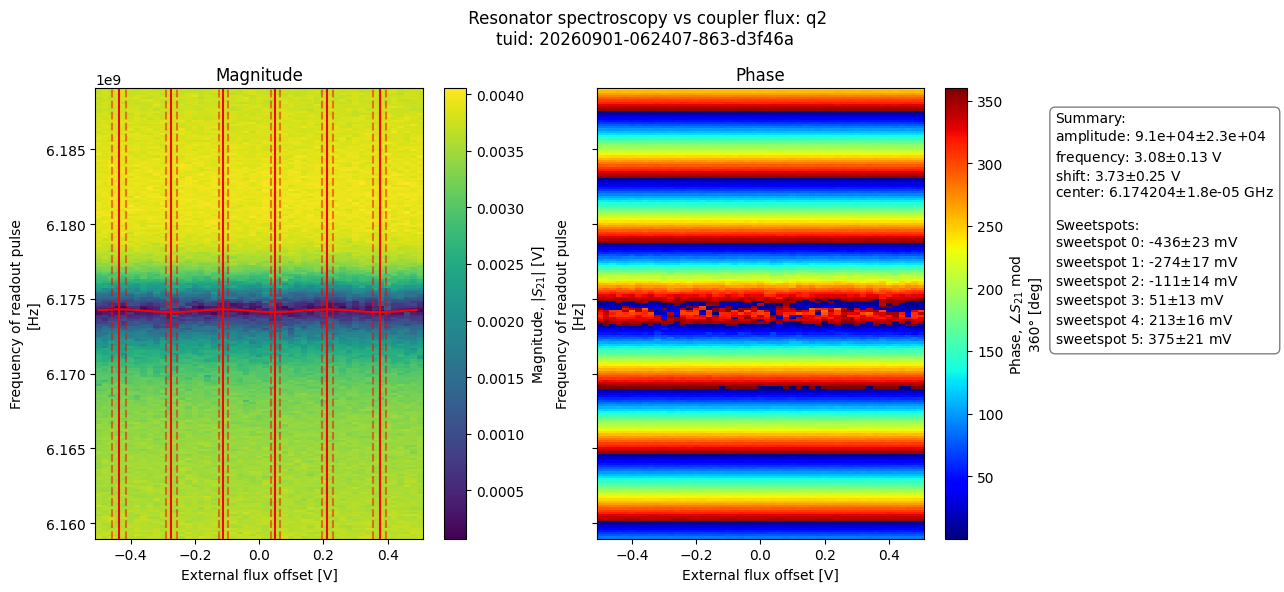

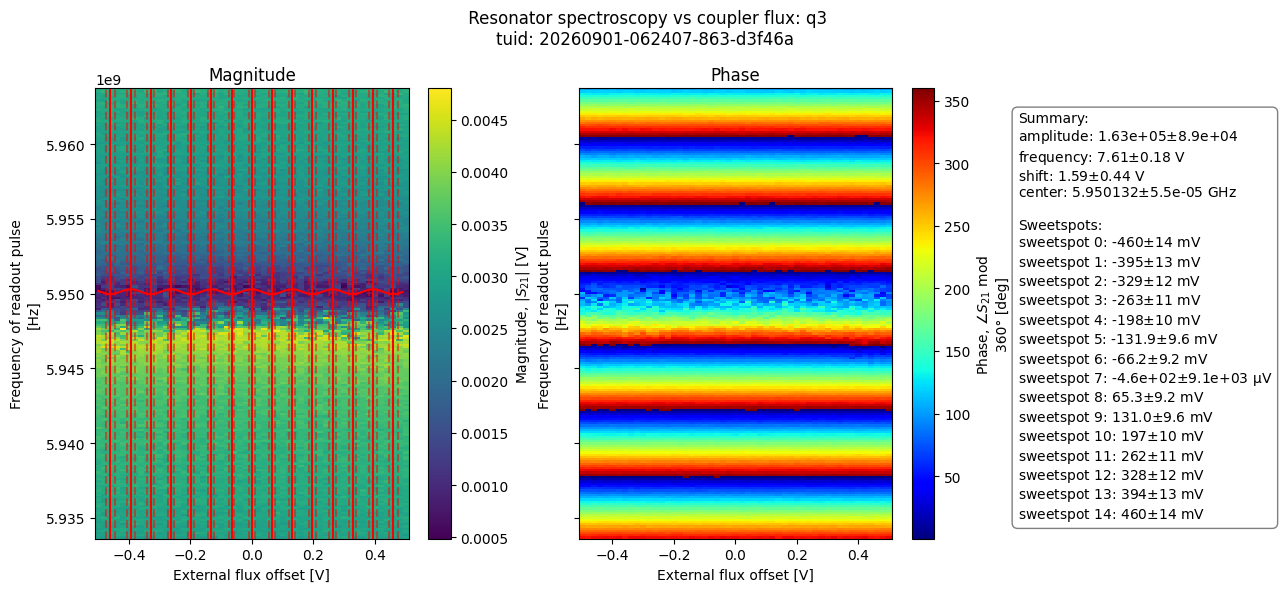

In [6]:
if PLOT_RESULTS:
    experiment.plot()


## Optional: apply and persist a selected coupler operating point

In [7]:
SELECTED_FLUX_BIAS = 0.0   # Set after inspecting the analysis
APPLY_SELECTED_FLUX_BIAS = False
SAVE_SELECTED_FLUX_BIAS = False


In [ ]:
if APPLY_SELECTED_FLUX_BIAS:
    if SELECTED_FLUX_BIAS is None:
        raise ValueError("Set SELECTED_FLUX_BIAS before applying a bias.")

    applied_bias = experiment.apply_flux_bias(SELECTED_FLUX_BIAS)
    print(f"{COUPLER}: live flux bias = {applied_bias:.6f} V")

    if SAVE_SELECTED_FLUX_BIAS:
        saved_path = experiment.save_flux_bias(
            FLUX_CONFIG,
            SELECTED_FLUX_BIAS,
        )
        print(f"Saved flux operating point to {saved_path}")


In [ ]:
if PLOT_RESULTS and experiment.figures:
    save_result_figures(SESSION, dataset, EXPERIMENT_NAME, experiment.figures)
save_config_snapshot(SESSION, dataset, EXPERIMENT_NAME)


## Release hardware connection

In [ ]:
from qcodes.instrument import Instrument

Instrument.close_all()
